In [1]:
from pystac_client import Client
from pystac import ItemCollection, Item
from odc.stac import stac_load
from pyproj import CRS
from xarray import Dataset, DataArray
import yaml
import geopandas as gpd
import logging
import os.path as op
import requests
from os import makedirs
import odc.stac
import planetary_computer
import matplotlib.pyplot as plt
import rioxarray as rio
from shapely.geometry import shape
import os

In [2]:
# downloaded tiger line data for all counties in the conterminous us
url = "https://www2.census.gov/geo/tiger/TIGER2025/COUNTY/tl_2025_us_county.zip"
us_counties = gpd.read_file(url)


In [3]:
montana_gdf = us_counties[us_counties['STATEFP'] == "30"].copy()
montana_gdf.head(), len(montana_gdf)

(    STATEFP COUNTYFP  COUNTYNS  GEOID         GEOIDFQ         NAME  \
 66       30      073  01719587  30073  0500000US30073      Pondera   
 85       30      055  01716270  30055  0500000US30055       McCone   
 113      30      067  01720027  30067  0500000US30067         Park   
 293      30      097  01719569  30097  0500000US30097  Sweet Grass   
 422      30      027  01719614  30027  0500000US30027       Fergus   
 
                NAMELSAD LSAD CLASSFP  MTFCC CSAFP CBSAFP METDIVFP FUNCSTAT  \
 66       Pondera County   06      H1  G4020   NaN    NaN      NaN        A   
 85        McCone County   06      H1  G4020   NaN    NaN      NaN        A   
 113         Park County   06      H1  G4020   NaN    NaN      NaN        A   
 293  Sweet Grass County   06      H1  G4020   NaN    NaN      NaN        A   
 422       Fergus County   06      H1  G4020   NaN    NaN      NaN        A   
 
            ALAND     AWATER     INTPTLAT      INTPTLON  \
 66    4207608377   43980663  +48.228

<Axes: >

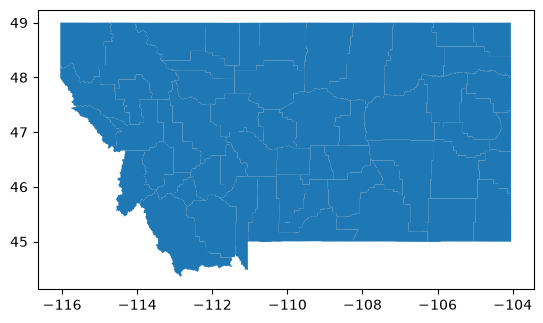

In [4]:
montana_gdf.plot()

Alright, Let's take a few counties and then set up a comparative analysis of NBR 1 year apart 

In [5]:
montana_gdf[montana_gdf['NAME'].str.contains('Ravalli')]

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
1711,30,081,01719582,30081,0500000US30081,Ravalli,Ravalli County,06,H1,G4020,NaN,NaN,NaN,A,6192574708,24289482,+46.0777441,-114.1057950,"POLYGON ((-114.42245 46.38705, -114.42221 46.3..."


In [6]:
rav_county = montana_gdf[montana_gdf['NAME'].str.contains('Ravalli')].copy()
# define crs
rav_county = rav_county.to_crs("EPSG: 4326")

poly = rav_county.dissolve()
poly = poly.to_crs("EPSG: 4326")


In [7]:
# The whole county of Ravalli is a bit large for this exercise so we will
# use an example from St. Mary Peak

aoi = gpd.read_file(r"/home/bily/python/montana-wildfire/data/raw/stMary_aoi.shp")
aoi = aoi.to_crs("EPSG: 4326")

poly = aoi.dissolve()
poly = poly.to_crs("EPSG: 4326")

In [8]:
def bbox_to_geom(bbox: list) -> dict:
    """Convert a bounding box to a geojson-formatted
    geometry.
    Arg:
        bbox (list): bouning box with coordinate order left, bottom, right, top
    Return:
        geometry (dict): geojson-formatted geometry, as a dict
    """
    geometry = {
      "type": "Polygon",
          "coordinates": [
            [
              [
                bbox[0],
                bbox[3]
              ],
              [
                bbox[0],
                bbox[1]
              ],
              [
                bbox[2],
                bbox[1]
              ],
              [
                bbox[2],
                bbox[3]
              ],
              [
                bbox[0],
                bbox[3]
              ]
            ]
          ],
  }

    return geometry

def make_datacube(items: ItemCollection, bands, resolution, bbox) -> Dataset:
    """Convert stac item collection into xarray Dataset object.
    Temporal compositing hard-coded to solar_day for now.
    Arg:
        items (pystac.ItemCollection): items to convert to datacube
    Return:
        dc (Dataset): space-time datacube
    """

    logging.info("Making datacube for items: %s", items.items)

    output_crs = CRS.from_epsg(items[0].properties["proj:code"].split(":")[1])

    dc = stac_load(
            items=items.items,
            bands=bands,
            resolution=resolution,
            groupby="solar_day",
            crs=output_crs,
            bbox=bbox,
            chunks={'x': 2048, 'y': 2048}
            )

    return dc

In [9]:
bbox = aoi.total_bounds
cat = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1", modifier=planetary_computer.sign_inplace)

Sometimes I define two date ranges a year apart and grab the average - to define an average value for a season and compare that to an average value against a different season (mainly looking at forest growth and harvest activities) - I kind of want to try searching and gathering a range and then seeing that change over time today

In [10]:
# Define the search parameters for early summer 2024
summer_start_date = "2024-06-01"
summer_end_date = "2024-07-24"

# Define the search parameters for Fall 2024
fall_start_date = "2024-09-01"
fall_end_date = "2024-10-31"

# Define the Landsat collection ID
collection = "sentinel-2-l2a"

search_kwargs_summer = {
    "max_items": 30,
    "limit": 10,
    "collections": collection,
    "datetime": f"{summer_start_date}/{summer_end_date}",
    "bbox": bbox,
    "query": {"eo:cloud_cover": {"lt": 10}}
}

search_kwargs_fall = {
    "max_items": 30,
    "limit": 10,
    "collections": collection,
    "datetime": f"{fall_start_date}/{fall_end_date}",
    "bbox": bbox,
    "query": {"eo:cloud_cover": {"lt": 10}}
}

In [11]:
# Perform the search for June 2015
search_summer = cat.search(**search_kwargs_summer)
# Perform the search for June 2016
search_fall = cat.search(**search_kwargs_fall)

# Get the search results
items_summer = search_summer.item_collection()
items_fall = search_fall.item_collection()


In [12]:
items = items_summer + items_fall
if len(items_summer) == 0 or len(items_fall) == 0:
    print(f"Skipping {_} due to no items found")

In [13]:
# check crs
epsg = items[0].properties["proj:code"]
epsg

'EPSG:32611'

In [14]:
bands = ["B08", "B12", "SCL"]
chunks = {'x': 2048, 'y': 2048}

In [15]:
# Filter items to only include those that fully intersect the polygon
filtered_items = []
for item in items:
    item_geom = shape(item.geometry)
    if item_geom.intersects(poly.geometry.iloc[0]):
        filtered_items.append(item)

print(f"Filtered {len(filtered_items)} Items that fully intersect the polygon:")

Filtered 35 Items that fully intersect the polygon:


In [16]:
dc = make_datacube(items=items, bands=bands, resolution=10, bbox=bbox)
dc.attrs["crs"] = f"epsg:{epsg}"

In [17]:
import pandas as pd
# 1. Create a dictionary mapping DATE to OFFSET from your 133 items
# Use .date() to match the 'solar_day' grouping behavior
offset_dict = {}
for item in items:
    date_key = pd.to_datetime(item.datetime).date()
    baseline = item.properties.get("s2:processing_baseline", "02.00")
    val = -1000 if float(baseline) >= 4.0 else 0
    offset_dict[date_key] = val

# 2. Map those dictionary values to the 118 dates actually in your dc
# This aligns the sizes perfectly (118 -> 118)
dc_dates = pd.to_datetime(dc.time.values).date
aligned_offsets = [offset_dict[d] for d in dc_dates]

# 3. attach offset to datacube to offset in case of pre and post 2022 data update
dc.coords["boa_offset"] = ("time", aligned_offsets)

b08 = dc[bands[0]]# + dc['boa_offset']
b12 = dc[bands[1]]# + dc['boa_offset']

dc_crs = dc[bands[1]].rio.crs

In [18]:
import numpy as np
nbr = (b08 - b12) / (b08 + b12)
# nbr = nbr.where(np.isfinite(nbr))

In [19]:
fall_nbr = nbr.sel(time=slice(fall_start_date, fall_end_date)).mean(dim='time')
fall_nbr = fall_nbr.rio.clip(poly.geometry.values, poly.crs)
fall_nbr = fall_nbr.rio.write_crs(dc_crs)

summer_nbr = nbr.sel(time=slice(summer_start_date, summer_end_date)).mean(dim='time')
summer_nbr = summer_nbr.rio.clip(poly.geometry.values, poly.crs)
summer_nbr = summer_nbr.rio.write_crs(dc_crs)

In [20]:
nbr_diff = summer_nbr - fall_nbr
nbr_diff = nbr_diff.rio.write_crs(dc_crs)

In [21]:
nbr_diff.compute()

/home/bily/python/montana-wildfire/.venv/lib/python3.12/site-packages/rasterio/warp.py:385: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


<xarray.DataArray (y: 3901, x: 3188)> Size: 50MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(3901, 3188), dtype=float32)
Coordinates:
  * y            (y) float64 31kB 5.167e+06 5.167e+06 ... 5.128e+06 5.128e+06
  * x            (x) float64 26kB 6.968e+05 6.968e+05 ... 7.287e+05 7.287e+05
    spatial_ref  int64 8B 0

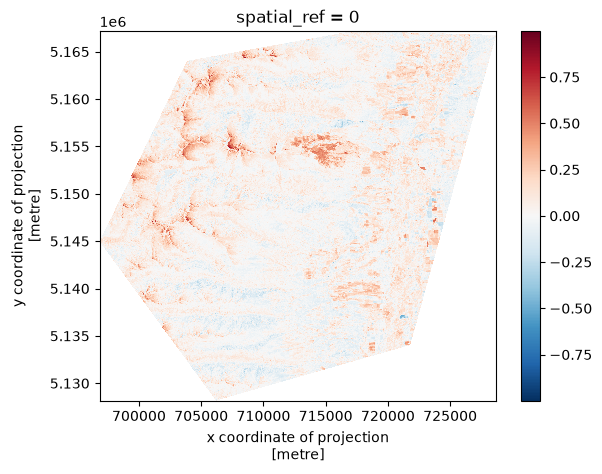

In [22]:
nbr_diff.plot()

In [23]:
print((b08 + b12).isel(time=0).values.min())
print((b08 - b12).isel(time=0).values.min())
print(nbr_diff.values.min())

1110.0


Some things I would like to add would be

- a cloud mask to get rid of particularly cloudy scenes
- a smoothing moving window function